##  Остовные деревья. Минимальное остовное дерево, алгоритмы Борувки, Прима, Краскала. 

#### 1.1. Основные понятия (напоминание)

* Граф $G = (V, E)$ — совокупность множества вершин $V$ и множества рёбер $E$, соединяющих пары вершин.

* Взвешенный граф — граф, каждому ребру которого присвоено число (вес). Обычно вес интерпретируется как стоимость, расстояние или пропускная способность.

* Связный граф — граф, в котором между любой парой вершин существует путь.

* Дерево — связный граф без циклов, обладающий следующими свойствами:

* Количество рёбер в дереве ровно на одно меньше количества вершин: $|E| = |V| - 1$.

* Между любыми двумя вершинами существует единственный путь.

#### 1.2. Остовное дерево (остов)

Остовным деревом (или просто остовом) связного графа $G$ называется такой подграф $T$, который:

* Содержит все вершины графа $G$ ($V_T = V_G$).

* Является деревом (т.е. связен и ацикличен)

Можно представить остовное дерево как минимальный набор дорог, соединяющих все города страны без образования круговых маршрутов. Это важно в задачах оптимизации, где нужно минимизировать стоимость или длину связей.

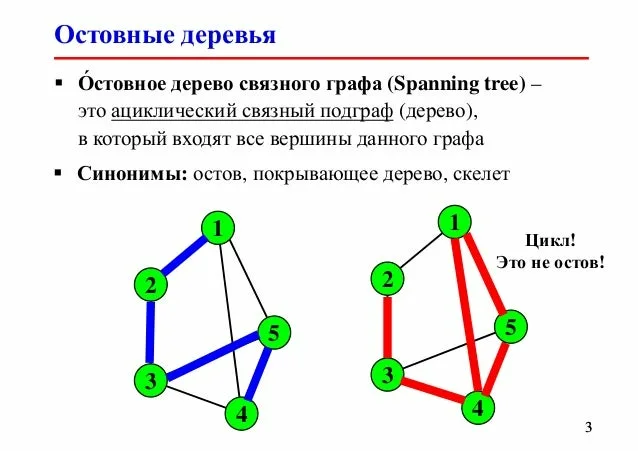


#### Теорема: остовное дерево связного графа
Теорема утверждает,что у любого связного графа существует остовное дерево.

Рассмотрим связный граф, который можно представить как структуру со множеством узлов и циклов. Наша задача — удалить из графа избыточные рёбра, сохраняя связность и избегая образования циклов.

Начинаем с исходного связного графа.
Пока присутствуют циклы, удаляем по одному ребру из каждого из них. Это сохраняет связность, но устраняет замкнутость.
В результате получаем граф без циклов, который остаётся связным, — остовное дерево.

#### 1.3. Минимальное остовное дерево (MST)

Определение: Если граф $G$ является взвешенным, то вес остова $T$ вычисляется как сумма весов всех его рёбер: $w(T) = \sum_{e \in E_T} w(e)$.
Минимальное остовное дерево (Minimum Spanning Tree, MST) — это остовное дерево, вес которого минимален среди всех возможных остовных деревьев данного графа.

Задача о MST: Для данного связного взвешенного неориентированного графа найти его минимальное остовное дерево.

Для нахождения минимального остовного дерева графа существуют два основных алгоритма: алгоритм Прима и алгоритм Крускала. Они оба имеют сложность O(MlogN)

##### Интуитивное понимание задачи

Представьте себе карту с несколькими городами (вершины графа), которые нужно соединить сетью дорог (рёбра графа) так, чтобы из любого города можно было добраться до любого другого (связность). Строительство каждой дороги между парой городов имеет свою стоимость (вес ребра). Задача: спроектировать сеть дорог таким образом, чтобы:

* Она соединяла все города (была связной).

* Общая стоимость строительства всех дорог была минимальной.

* В сети не было лишних, дублирующих дорог (циклов), так как удаление любого ребра из цикла сохранит связность, но уменьшит стоимость.

Именно такой оптимальный набор дорог и будет минимальным остовным деревом.

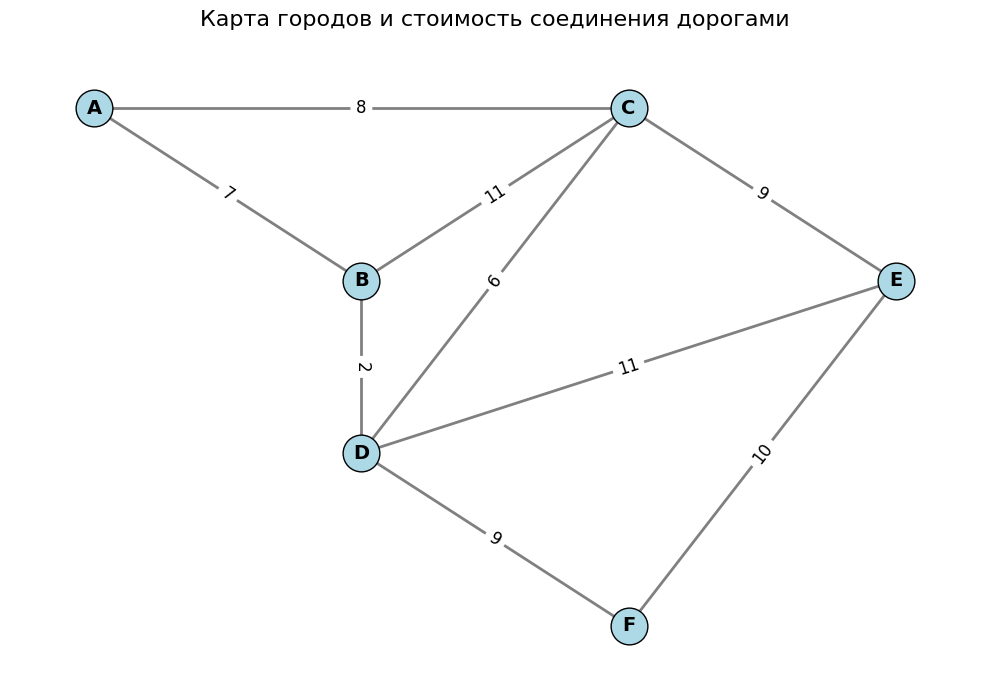

Красным выделены рёбра, входящие в MST. Их суммарный вес = 2+6+7+9+9 = 33
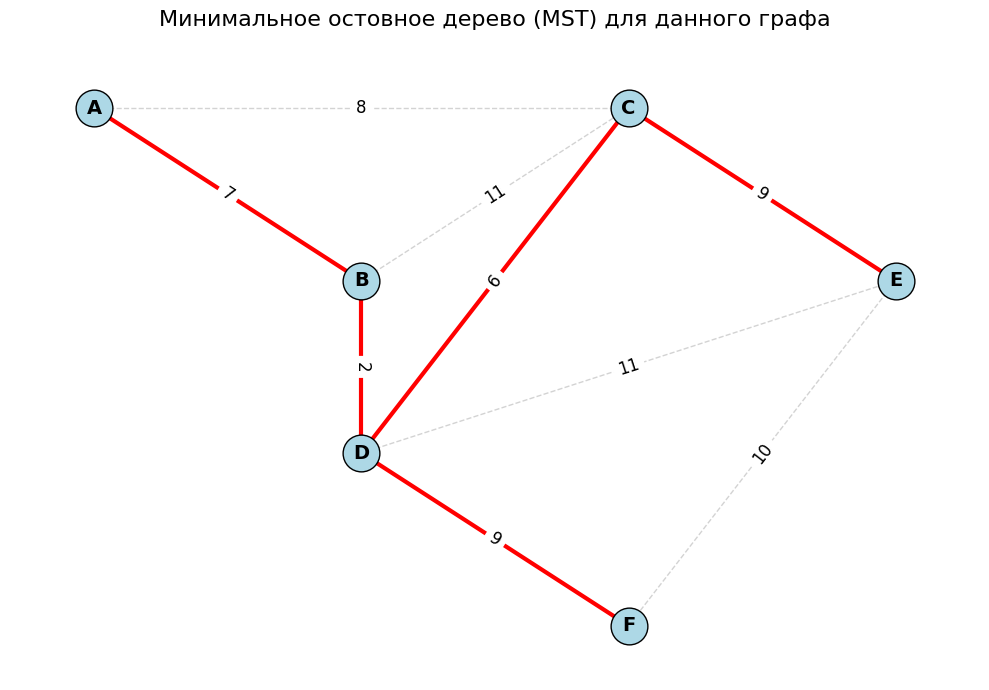

#### 2. Общая идея жадных алгоритмов
Все три классических алгоритма (Борувки, Прима, Краскала) являются жадными. Это означает, что на каждом шаге они принимают локально оптимальное решение (выбирают ребро с наименьшим весом), которое в итоге приводит к глобальному оптимуму — построению MST. Работа алгоритмов базируется на двух ключевых свойствах MST:

* Свойство безопасного ребра (cut property): Рассмотрим произвольный разрез графа (разбиение множества вершин $V$ на два непересекающихся подмножества $S$ и $V \setminus S$). Среди всех рёбер, пересекающих этот разрез (т.е. соединяющих вершины из $S$ с вершинами из $V \setminus S$), ребро с минимальным весом обязательно будет принадлежать какому-то минимальному остовному дереву.

* Свойство цикла (cycle property): Если в графе есть цикл, то самое тяжелое ребро в этом цикле не принадлежит ни одному MST.

#### Иллюстрация ключевых свойств minimal spanning tree (MST)

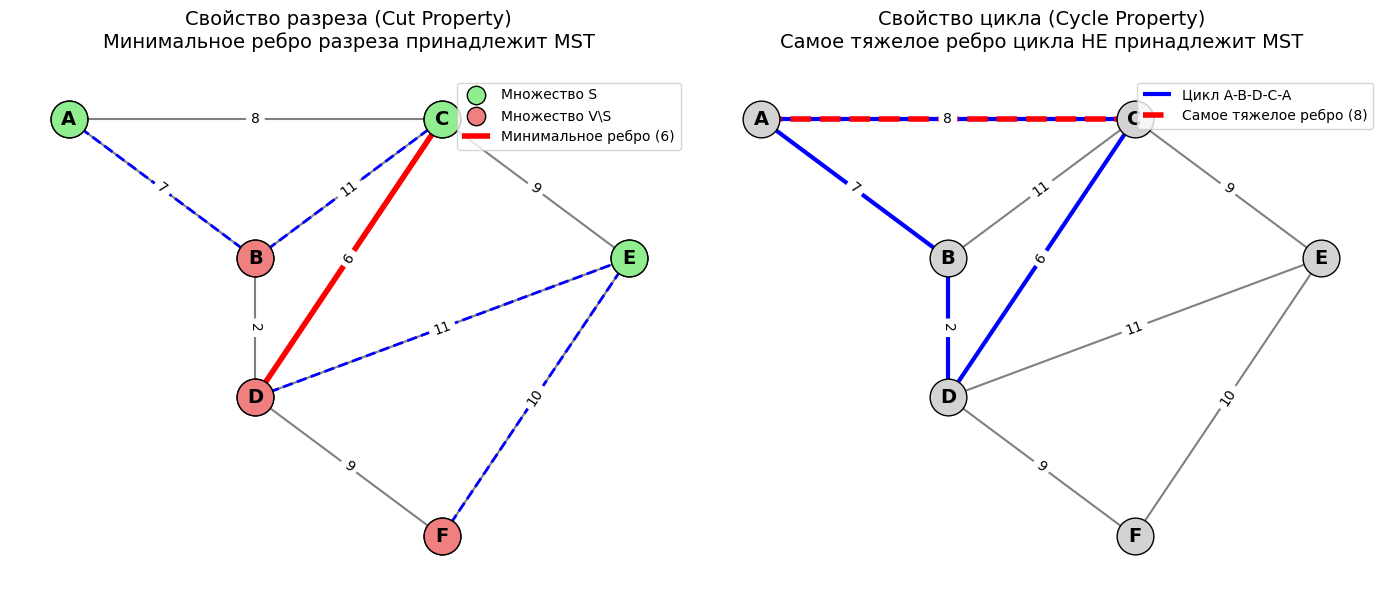

СВОЙСТВО РАЗРЕЗА (левая часть):
  * Множество S = {A, C, E} (зеленые вершины)
  * Множество V\S = {B, D, F} (красные вершины)
  * Синим пунктиром показаны ребра, пересекающие разрез
  * Красным выделено минимальное ребро разреза: C-D (вес 6)
  * Это ребро ОБЯЗАТЕЛЬНО войдет в некоторое MST

СВОЙСТВО ЦИКЛА (правая часть):
  * Синим выделен цикл A-B-D-C-A
  * Веса ребер в цикле: A-B(7), B-D(2), D-C(6), C-A(8)
  * Красным пунктиром выделено самое тяжелое ребро цикла: C-A (вес 8)
  * Это ребро НЕ войдет ни в одно MST

Эти два свойства лежат в основе работы всех жадных алгоритмов поиска MST:
  * Алгоритм Прима использует свойство разреза, на каждом шаге добавляя
    минимальное ребро, соединяющее построенное дерево с остальными вершинами
  * Алгоритм Краскала использует свойство цикла, отбрасывая ребра,
    которые могут образовать цикл с уже выбранными более легкими ребрами
  * Алгоритм Борувки комбинирует оба подхода, работая параллельно

РЕАЛЬНОЕ MST ДЛЯ ДАННОГО ГРАФА (найдено алгоритмом Краскала):
  Рёбра MST: B-D, C-D, A-B, C-E, D-F
  Вес MST: 33

Проверка свойства разреза:
  Ребро C-D (минимальное в разрезе) ВХОДИТ в MST 

Проверка свойства цикла:
  Ребро C-A (самое тяжелое в цикле) НЕ ВХОДИТ в MST 

### 3. Алгоритм Краскала (Kruskal's Algorithm)
Этот алгоритм наиболее интуитивно понятен. Он строит MST, постепенно объединяя изолированные вершины в лес, который в конце концов становится единым деревом.

##### Теоретическая основа
Механизм, по которому работает данный алгоритм, очень прост. На входе имеется пустой подграф, который и будем достраивать до потенциального минимального остовного дерева. Будем рассматривать только связные графы, в другом случае при применении алгоритма Краскала мы будем получать не минимальное остовное дерево, а просто остовной лес.

* Вначале мы производим сортировку рёбер по неубыванию по их весам.

* Добавляем i-ое ребро в наш подграф только в том случае, если данное ребро соединяет две разные компоненты связности, одним из которых является наш подграф. То есть, на каждом шаге добавляется минимальное по весу ребро, один конец которого содержится в нашем подграфе, а другой - еще нет.

* Алгоритм завершит свою работу после того, как множество вершин нашего подграфа совпадет с множеством вершин исходного графа.

Данный алгоритм называется жадным из-за того, что мы на каждом шаге пытаемся найти оптимальный вариант, который приведет к оптимальному решению в целом.

#### Разбор конкретного примера по шагам

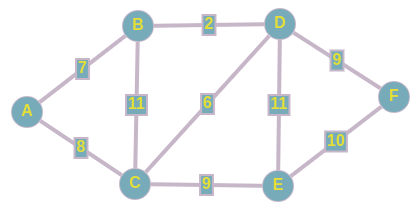

Из представленного сверху графа, выпишем все его ребра в отсортированном порядке:

1) D <--> B; w = 2
2) D <--> C; w = 6
3) A <--> B; w = 7
4) A <--> C; w = 8
5) C <--> E; w = 9
6) D <--> F; w = 9
7) F <--> E; w = 10
8) B <--> C; w = 11
9) D <--> E; w = 11

И начнем по списку добавлять эти ребра в наш остов:

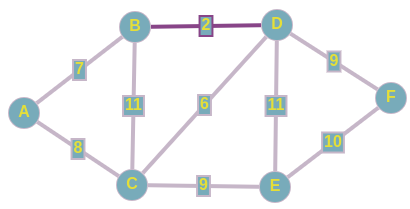
Подграф после добавления 1-го ребра


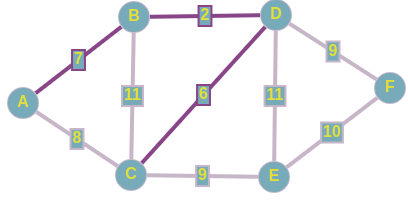
Подграф после добавления 2-го и 3-го рёбер


При добавлении в наше остовное дерево ребра A <--> C, как вы можете заметить, образовывается цикл, поэтому мы просто пропускаем данное ребро.

По итогу у нас образовывается следующий подграф, и как вы заметили, мы соединили все вершины ребрами с минимально-возможными весами, а значит, нашли минимальное остовное дерево для нашего исходного графа.


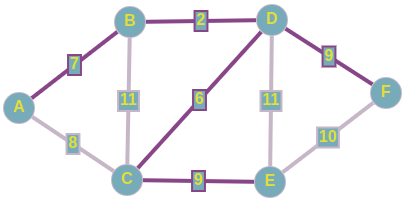
Минимальный остов


Суммарный вес искомого MST равен 33

### Реализация

Реализовать представленный алгоритм проще всего с помощью СНМ(система непересекающихся отрезков).

Вначале, как мы уже раннее говорили, необходимо отсортировать ребра по неубыванию по их весам. Далее с помощью вызовов функции make_set()мы каждую вершину можем поместить в свое собственное дерево, то есть, создаем некоторое множество подграфов. Дальше итерируемся по всем ребрам в отсортированном порядке и смотрим, принадлежат ли инцидентные вершины текущего ребра разным подграфам с помощью функции find_set() или нет, если оба конца лежат в разных компонентах, то объединяем два разных подграфа в один с помощью функции union_sets().

Алгоритм Краскала(G):
Вход: Граф G с множеством вершин V и рёбер E, весовая функция w.

1.  Инициализация:
    - result = [] // пустой список для хранения рёбер MST
    - cost = 0    // общий вес MST
    - Для каждой вершины v из V:
        Создать отдельное множество (компоненту), содержащее v.

2.  Сортировка:
    - Отсортировать все рёбра из E по возрастанию веса w.

3.  Основной цикл:
    - Для каждого ребра (u, v) с весом weight в отсортированном списке:
        - Если find_set(u) != find_set(v): // вершины в разных компонентах
            - result.add( (u, v, weight) )
            - cost = cost + weight
            - union_sets(u, v) // объединить компоненты

4.  Возврат:
    - Возвращаем result и cost.

### План реализации на Python

Реализовать класс DSU (Disjoint Set Union) с методами make_set (или инициализация в конструкторе), find (сжатие путей) и union (объединение по рангу/размеру).

Создать список рёбер графа в формате (вес, вершина_1, вершина_2).

Отсортировать список рёбер по весу.

Инициализировать DSU для всех вершин графа.

Пройти по отсортированным рёбрам. Для каждого ребра проверить, находятся ли его вершины в разных множествах DSU. Если да — добавить ребро в результат и объединить множества.

In [5]:
class DSU:
    """Система непересекающихся множеств (Union-Find)"""
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        # Сжатие путей
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        # Объединение по рангу
        x_root, y_root = self.find(x), self.find(y)
        if x_root == y_root:
            return False
        if self.rank[x_root] < self.rank[y_root]:
            self.parent[x_root] = y_root
        elif self.rank[x_root] > self.rank[y_root]:
            self.parent[y_root] = x_root
        else:
            self.parent[y_root] = x_root
            self.rank[x_root] += 1
        return True

def kruskal_mst(vertices_count, edges):
    """
    edges: список кортежей (weight, u, v)
    Возвращает: (общий_вес, список_рёбер_mst)
    """
    # Сортируем рёбра по весу
    sorted_edges = sorted(edges, key=lambda edge: edge[0])
    
    dsu = DSU(vertices_count)
    mst_edges = []
    total_weight = 0
    
    for weight, u, v in sorted_edges:
        # Если вершины в разных компонентах, добавляем ребро
        if dsu.union(u, v):
            mst_edges.append((u, v, weight))
            total_weight += weight
            
    return total_weight, mst_edges

# Пример использования
if __name__ == "__main__":
    # Граф из примера (вершины: A=0, B=1, C=2, D=3, E=4, F=5)
    V = 6
    # Веса рёбер (weight, u, v)
    graph_edges = [
        (7, 0, 1),   # A-B
        (8, 0, 2),   # A-C
        (11, 1, 2),  # B-C
        (2, 1, 3),   # B-D
        (6, 2, 3),   # C-D
        (9, 2, 4),   # C-E
        (11, 3, 4),  # D-E
        (9, 3, 5),   # D-F
        (10, 4, 5)   # E-F
    ]
    
    total_cost, mst = kruskal_mst(V, graph_edges)
    print(f"Алгоритм Краскала: Вес MST = {total_cost}")
    print("Рёбра в MST:")
    for u, v, w in mst:
        print(f"{chr(65+u)} -- {chr(65+v)} : {w}")
    # Ожидаемый вес: 33

Алгоритм Краскала: Вес MST = 33
Рёбра в MST:
B -- D : 2
C -- D : 6
A -- B : 7
C -- E : 9
D -- F : 9


### 4. Алгоритм Прима (Prim's Algorithm)

Суть самого алгоритма Прима тоже сводится к жадному перебору рёбер, но уже из определенного множества. На входе так же имеется пустой подграф, который и будем достраивать до потенциального минимального остовного дерева.

Изначально наш подграф состоит из одной любой вершины исходного графа.

Затем из рёбер инцидентных этой вершине, выбирается такое минимальное ребро, которое связала бы две абсолютно разные компоненты связности, одной из которых и является наш подграф. То есть, как только у нас появляется возможность добавить новую вершину в наш подграф, мы тут же включаем ее по минимальмально возможному весу.

Продолжаем выполнять предыдущий шаг до тех пор, пока не найдем искомое MST.

#### Разбор конкретного примера
Выбираем чисто случайно вершину E,далее рассмотрим все ребра исходящие из нее, включаем в наше остовное дерево ребро C <--> E; w = 9, так как данное ребро имеет минимальный вес из всех рёбер инцидентных множеству вершин нашего подграфа. Имеем следующее:


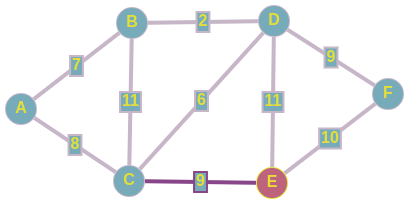
Подграф после добавления 1-го ребра

Теперь выборка производится из рёбер:
 D <--> C; w = 6
 A <--> C; w = 8
 F <--> E; w = 10
 B <--> C; w = 11
 D <--> E; w = 11

То есть, в данный момент, мы знаем только о двух вершинах, соответственно, знаем о всех ребрах, исходящих из них. Про связи между другими вершинами, которые не включены в наш подграф, мы ничего не знаем, поэтому они на этом шаге не рассматриваются.

Добавляем в наш подграф ребро D <--> C и по аналогии добаляем ребро D <--> B. Получаем следующее:


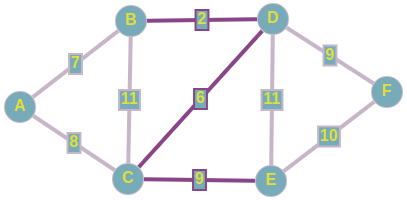
Подграф, полученный после добавления рассмотренных рёбер


Давайте добьем наш подграф до минимального остовного дерева. Вы, наверное, уже догадались о том, по каким ребрам мы будем связывать наши оставшиеся вершины:
A и F.

Проводим последние штрихи и получили тот же самый подграф в качестве минимального остовного дерева. Но как мы раннее говорили, сам подграф ничего не решает, главное тут - множество рёбер, которые включены в наше остовное дерево.

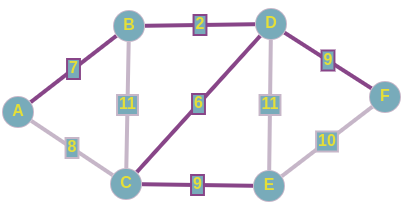
Искомое минимальное остовное дерево

### Псевдокод алгоритма

Для эффективного поиска минимального ребра, соединяющего построенное дерево с остальными вершинами, используется очередь с приоритетами (min-heap).

Алгоритм Прима(G, start):
Вход: Граф G, стартовая вершина start.

1.  Инициализация:
    - priority_queue = [] // мин-куча для хранения рёбер (вес, вершина)
    - in_mst = [False] * |V| // массив меток, включена ли вершина в MST
    - mst_edges = []
    - total_cost = 0

2.  Добавить стартовую вершину в дерево:
    - in_mst[start] = True
    - Для каждого соседа v вершины start с весом w:
        Добавить в очередь (w, start, v) // запоминаем и ребро

3.  Основной цикл (пока не набрали |V|-1 рёбер):
    - Извлечь из кучи ребро с минимальным весом (w, u, v).
    - Если вершина v уже in_mst[v] == True: пропустить ребро (этот случай может быть, если вершину добавили позже).
    - Иначе (v еще не в дереве):
        - Добавить ребро (u, v) в mst_edges
        - total_cost += w
        - Пометить v как in_mst[v] = True
        - Для каждого соседа w вершины v:
            Если сосед w еще не в дереве:
                Добавить в очередь (weight(v, w), v, w)

4.  Возврат: mst_edges, total_cost

### План реализации на Python

1. Представить граф в виде списка смежности: graph[vertex] = [(neighbor, weight), ...].

2. Использовать модуль heapq для реализации очереди с приоритетами.

3. Завести массив in_mst для отслеживания посещённых вершин.

4. Начать с вершины 0 (или любой другой). Добавить все её рёбра в кучу.

5. Пока куча не пуста и количество рёбер в MST меньше V-1:

6. Извлечь минимальное ребро (weight, from_vertex, to_vertex).

7. Если to_vertex уже в дереве, continue.

8. Добавить to_vertex в дерево: отметить in_mst, добавить ребро в результат, увеличить вес.

9. Добавить в кучу все рёбра от to_vertex к ещё не посещённым вершинам.

In [ ]:
import heapq

def prim_mst(graph, start=0):
    """
    graph: список смежности graph[vertex] = [(neighbor, weight), ...]
    Возвращает: (общий_вес, список_рёбер_mst)
    """
    n = len(graph)
    in_mst = [False] * n
    mst_edges = []
    total_weight = 0
    # Куча содержит кортежи (weight, from_vertex, to_vertex)
    # Изначально добавляем все рёбра из стартовой вершины
    priority_queue = []
    
    # Функция для добавления рёбер вершины v в кучу
    def add_edges(v):
        in_mst[v] = True
        for to, w in graph[v]:
            if not in_mst[to]:
                heapq.heappush(priority_queue, (w, v, to))
    
    # Начинаем со стартовой вершины
    add_edges(start)
    
    while priority_queue and len(mst_edges) < n - 1:
        weight, u, v = heapq.heappop(priority_queue)
        # Если вершина v уже добавлена, пропускаем (она могла быть добавлена через другой путь)
        if in_mst[v]:
            continue
        
        # Добавляем ребро в MST
        mst_edges.append((u, v, weight))
        total_weight += weight
        # Добавляем все рёбра из новой вершины
        add_edges(v)
    
    return total_weight, mst_edges

# Пример использования для того же графа (построим список смежности)
if __name__ == "__main__":
    V = 6
    adj_list = [[] for _ in range(V)]
    # Веса рёбер (weight, u, v) - добавляем в обе стороны
    edges_data = [
        (7, 0, 1), (8, 0, 2), (11, 1, 2), (2, 1, 3), (6, 2, 3),
        (9, 2, 4), (11, 3, 4), (9, 3, 5), (10, 4, 5)
    ]
    for w, u, v in edges_data:
        adj_list[u].append((v, w))
        adj_list[v].append((u, w))
    
    total_cost, mst = prim_mst(adj_list, start=0) # Начнем с вершины A
    print(f"\nАлгоритм Прима: Вес MST = {total_cost}")
    print("Рёбра в MST:")
    for u, v, w in mst:
        print(f"{chr(65+u)} -- {chr(65+v)} : {w}")
    # Ожидаемый вес: 33

Анализ сложности: С использованием бинарной кучи — $O(E \log V)$. Это эффективнее алгоритма Краскала на разреженных графах.

### 5. Алгоритм Борувки (Borůvka's Algorithm)

Алгоритм Борувки также является жадным. Изначально граф состоит из изолированных вершин (компонент связности). На каждом этапе для каждой компоненты связности выбирается самое дешёвое ребро, которое соединяет эту компоненту с какой-либо другой компонентой. Затем все выбранные рёбра добавляются в MST (они объединяют компоненты). Процесс повторяется, пока не останется одна компонента.

#### Алгоритм Борувики пошагово

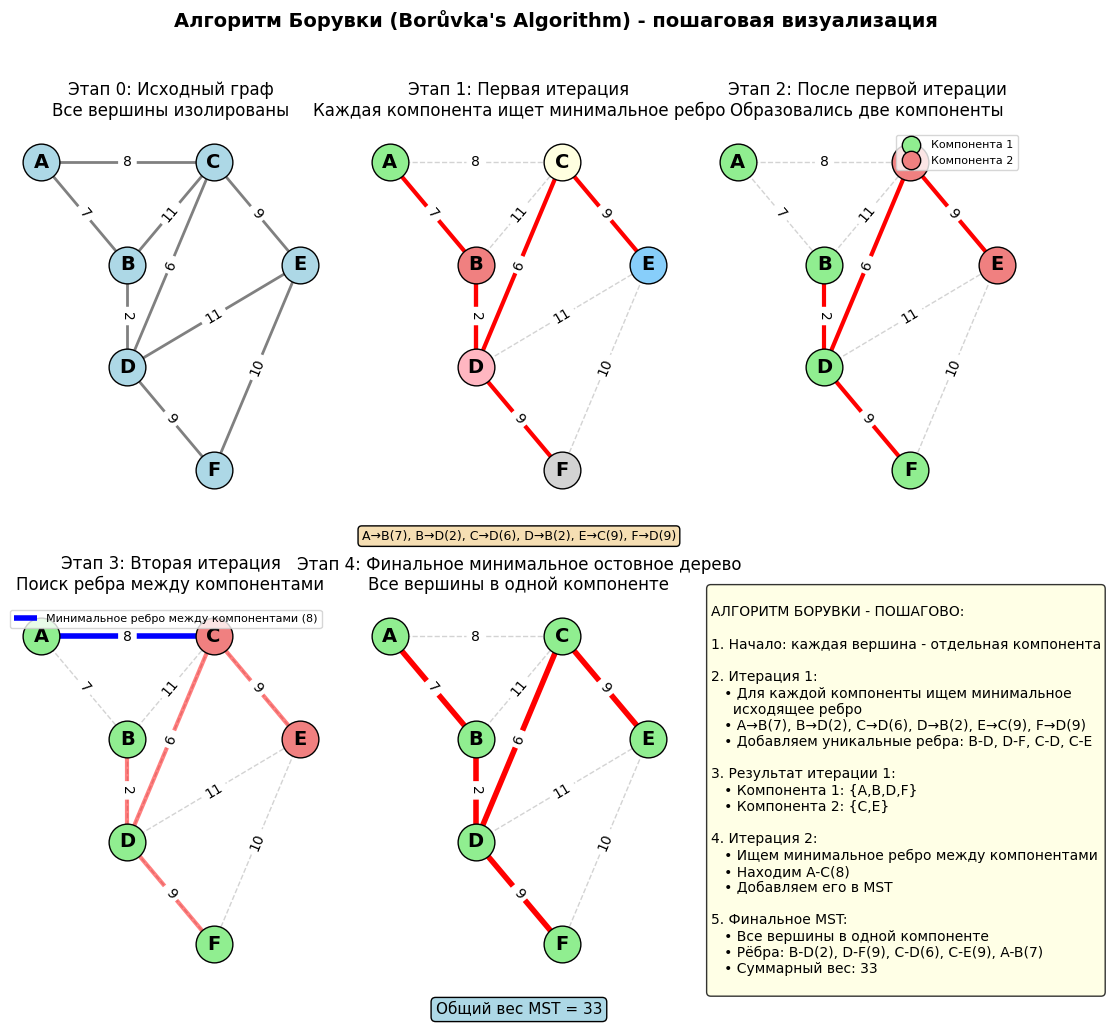

#### Псевдокод алгоритма

Алгоритм Борувки(G):
Вход: Граф G.

1.  Инициализация:
    - result = []
    - Каждая вершина является отдельной компонентой связности.

2.  Пока количество компонент связности > 1:
        - cheapest_edge = [] // массив для хранения самого дешёвого исходящего ребра для каждой компоненты
        - Для каждого ребра (u, v) с весом w в графе:
            - comp_u = компонента(u)
            - comp_v = компонента(v)
            - Если comp_u != comp_v:
                - Если cheapest_edge[comp_u] не существует или w < вес cheapest_edge[comp_u]:
                    - cheapest_edge[comp_u] = (u, v, w)
                - Если cheapest_edge[comp_v] не существует или w < вес cheapest_edge[comp_v]:
                    - cheapest_edge[comp_v] = (u, v, w)
        - Для каждой компоненты comp:
            - Если cheapest_edge[comp] существует и её ребро (u, v, w) ещё не добавлено в result:
                - Добавить ребро в result
                - Объединить компоненты comp_u и comp_v

3.  Возврат: result

#### План реализации на Python
1. Вновь использовать DSU для отслеживания компонент связности.

2. В цикле while, пока количество компонент больше 1:

3. Создать массив cheapest размером n, заполненный, например, значением None.

4. Пройти по всем рёбрам графа. Для каждого ребра найти компоненты его концов. Если компоненты разные, обновить запись cheapest для каждой из этих компонент, если текущее ребро легче, чем найденное ранее для этой компоненты.

5. Пройти по всем компонентам. Если для компоненты найдено ребро (cheapest не None), попытаться добавить его в MST (объединить компоненты, которые оно соединяет).

In [ ]:
def boruvka_mst(vertices_count, edges):
    """
    edges: список кортежей (weight, u, v)
    Возвращает: общий_вес MST
    """
    dsu = DSU(vertices_count)
    mst_weight = 0
    num_components = vertices_count
    
    # Словарь для хранения самого дешёвого ребра для каждой компоненты на текущей итерации
    # (индекс компоненты -> (weight, u, v))
    
    # Пока не останется одна компонента
    iteration = 0
    while num_components > 1:
        iteration += 1
        # cheapest[comp_id] = (weight, u, v)
        cheapest = [-1] * vertices_count
        # cheapest_weight[comp_id] = weight для удобства сравнения
        cheapest_weight = [float('inf')] * vertices_count
        
        # 1. Находим самое дешёвое исходящее ребро для каждой компоненты
        for weight, u, v in edges:
            comp_u = dsu.find(u)
            comp_v = dsu.find(v)
            if comp_u != comp_v:
                # Для компоненты comp_u
                if weight < cheapest_weight[comp_u]:
                    cheapest_weight[comp_u] = weight
                    cheapest[comp_u] = (weight, u, v)
                # Для компоненты comp_v
                if weight < cheapest_weight[comp_v]:
                    cheapest_weight[comp_v] = weight
                    cheapest[comp_v] = (weight, u, v)
        
        # 2. Добавляем найденные рёбра в MST
        edges_added_this_phase = 0
        for comp in range(vertices_count):
            if cheapest[comp] != -1:
                weight, u, v = cheapest[comp]
                # Проверяем, не соединились ли компоненты уже в этой итерации
                if dsu.find(u) != dsu.find(v):
                    dsu.union(u, v)
                    mst_weight += weight
                    edges_added_this_phase += 1
                    num_components -= 1
        
        # Если на фазе не добавлено ни одного ребра, граф, вероятно, несвязен
        if edges_added_this_phase == 0:
            print("Граф несвязен, невозможно построить MST.")
            return -1
            
    return mst_weight

# Пример использования
if __name__ == "__main__":
    V = 6
    graph_edges = [
        (7, 0, 1), (8, 0, 2), (11, 1, 2), (2, 1, 3), (6, 2, 3),
        (9, 2, 4), (11, 3, 4), (9, 3, 5), (10, 4, 5)
    ]
    
    total_cost = boruvka_mst(V, graph_edges)
    print(f"\nАлгоритм Борувки: Вес MST = {total_cost}")
    # Ожидаемый вес: 33

### Источники и литература
1. Кормен, Т., Лейзерсон, Ч., Ривест, Р., Штайн, К. Алгоритмы: построение и анализ (Introduction to Algorithms). — Классическое издание с подробным разбором MST.

2. Статья на Habr: "Алгоритм Краскала, Прима для нахождения минимального остовного дерева". — https://habr.com/ru/articles/569444/. (Использована для примеров и псевдокода).

3. Лекции и конспекты: Открытые курсы по дискретной математике и алгоритмам на Coursera, Stepik, Яндекс образование

4. DeepSeek

## Задачи

#### Остовное дерево (Spanning Tree)

##### Условие задачи
Даны точки на плоскости, являющиеся вершинами **полного графа**. Вес каждого ребра равен **евклидову расстоянию** между соответствующими точками. Требуется найти в этом графе **минимальное остовное дерево (MST)**.

**Формальная постановка:**
- Имеется полный граф $G = (V, E)$, где $|V| = n$
- Каждая вершина $v_i$ задана координатами $(x_i, y_i)$ на плоскости
- Вес ребра $(i, j)$ вычисляется по формуле:
  
  $$w(i, j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$
  
- Требуется найти остовное дерево минимального суммарного веса

---

### Формат входного файла 

| Строка | Содержание | Примечание |
|--------|------------|------------|
| 1 | `n` | количество вершин ($1 \leq n \leq 5000$) |
| 2 .. n+1 | `x_i y_i` | координаты i-й вершины ($-10000 \leq x_i, y_i \leq 10000$) |

**Важно:** Никакие две точки не совпадают.

---

### Формат выходного файла

Одна строка, содержащая **одно вещественное число** — вес минимального остовного дерева.

---

### Пример

| `вход` | `выход` |
|---------------|----------------|
| 3<br>0 0<br>1 0<br>0 1 | 2 |

**Пояснение примера:**
- Вершины: A(0,0), B(1,0), C(0,1)
- Расстояния: AB = 1, AC = 1, BC = √2 ≈ 1.414
- Минимальное остовное дерево: рёбра AB (1) и AC (1)
- Суммарный вес: 2

#### Требования к алгоритму:
- Временная сложность: $O(n^2)$ или лучше
- Память: $O(n)$ (не хранить всю матрицу расстояний)

In [ ]:
import math


def dist(x1, y1, x2, y2):
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)


def mst(p):
    n = len(p)
    if n <= 1:
        return 0
    if n == 2:
        return dist(p[0][0], p[0][1], p[1][0], p[1][1])
    u = [False] * n
    d = [float('inf')] * n
    d[0] = 0
    res = 0
    for _ in range(n):
        mind = float('inf')
        v = -1
        for i in range(n):
            if not u[i] and d[i] < mind:
                mind = d[i]
                v = i
        u[v] = True
        res += mind
        x1, y1 = p[v]
        for to in range(n):
            if not u[to]:
                cur = dist(x1, y1, p[to][0], p[to][1])
                if cur < d[to]:
                    d[to] = cur
    return res


n = int(input().strip())
p = []
for _ in range(n):
    line = input().strip()
    while line == "":
        line = input().strip()
    x, y = map(int, line.split())
    p.append((x, y))
ans = mst(p)
print(f"{ans:.2f}")


2.0000000000


## Задача
1. Дан словарь различных слов и доска размером M x L, где в каждой ячейке есть один символ. Найдите все возможные слова из словаря, которые могут быть образованы последовательностью соседних символов на доске. Разрешено перемещение к любой из 8 соседних ячеек.

    Примечание:

    При формировании слова мы можем переместиться в любую из 8 соседних ячеек. Ячейка может быть использована только один раз в одном слове.

    Формат входных данных

    На вход программе в первой строке подаётся число слов в словаре N. В словаре минимум одно слово. В следующей строке передаётся словарь. В последующей строке два числа M и L - размер доски M x L и далее расположение букв на доске в виде {{буквы 1-й строки},{ буквы 2-й строки },{и т. д.}}.

    Формат выходных данных

    Вывести слова, которые можно образовать в отсортированном порядке в одной строке через пробел.

    Примеры

    Ввод:

    4 \
    GEEKS FOR QUIZ GO \
    3 3 \
    G I Z \
    U E K \
    Q S E

    Вывод:

    GEEKS QUIZ

In [ ]:
class Node:
    def __init__(self):
        self.ch = {}
        self.end = False
        self.w = None


class Tr:
    def __init__(self):
        self.root = Node()

    def add(self, word):
        cur = self.root
        for c in word:
            if c not in cur.ch:
                cur.ch[c] = Node()
            cur = cur.ch[c]
        cur.end = True
        cur.w = word


def find(b, words):
    if not b or not b[0]:
        return []
    n, m = len(b), len(b[0])
    t = Tr()
    for w in words:
        t.add(w)
    res = set()
    vis = [[False] * m for _ in range(n)]
    dirs = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),          (0, 1),
        (1, -1),  (1, 0), (1, 1)
    ]

    def go(i, j, node):
        c = b[i][j]
        if c not in node.ch:
            return
        node = node.ch[c]
        if node.end:
            res.add(node.w)
        vis[i][j] = True
        for di, dj in dirs:
            ni, nj = i + di, j + dj
            if 0 <= ni < n and 0 <= nj < m and not vis[ni][nj]:
                go(ni, nj, node)
        vis[i][j] = False
    for i in range(n):
        for j in range(m):
            go(i, j, t.root)
    return sorted(res)


n = int(input())
ws = input().split()
n, m = map(int, input().split())
b = []
for _ in range(n):
    row = input().split()
    b.append(row)
ans = find(b, ws)
print(' '.join(ans))


## Задача
2. Реализуйте алгоритм Прима и алгоритм Краскала и сравните их время работы на одних и тех же входных данных (порядка 10-20 тестов). Определите алгоритмическую сложность этих алгоритмов.

In [ ]:
import math
import time
import random


def dist(x1, y1, x2, y2):
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)


class DSU:
    def __init__(self, n):
        self.p = list(range(n))
        self.r = [0] * n

    def find(self, x):
        if self.p[x] != x:
            self.p[x] = self.find(self.p[x])
        return self.p[x]

    def union(self, x, y):
        xr, yr = self.find(x), self.find(y)
        if xr == yr:
            return False
        if self.r[xr] < self.r[yr]:
            self.p[xr] = yr
        elif self.r[xr] > self.r[yr]:
            self.p[yr] = xr
        else:
            self.p[yr] = xr
            self.r[xr] += 1
        return True


def prim(p):
    n = len(p)
    if n <= 1:
        return 0
    used = [False] * n
    d = [float('inf')] * n
    d[0] = 0
    res = 0
    for _ in range(n):
        mind = float('inf')
        v = -1
        for i in range(n):
            if not used[i] and d[i] < mind:
                mind = d[i]
                v = i
        used[v] = True
        res += mind
        x1, y1 = p[v]
        for to in range(n):
            if not used[to]:
                cur = dist(x1, y1, p[to][0], p[to][1])
                if cur < d[to]:
                    d[to] = cur
    return res


def kruskal(n, e):
    e.sort(key=lambda x: x[0])
    dsu = DSU(n)
    res = 0
    cnt = 0
    for w, u, v in e:
        if dsu.union(u, v):
            res += w
            cnt += 1
            if cnt == n - 1:
                break
    return res


def gen(n):
    p = []
    for _ in range(n):
        x = random.randint(-10000, 10000)
        y = random.randint(-10000, 10000)
        p.append((x, y))
    e = []
    for i in range(n):
        for j in range(i + 1, n):
            w = dist(p[i][0], p[i][1], p[j][0], p[j][1])
            e.append((w, i, j))
    return p, e


sz = [10, 20, 50, 100, 1000, 1500, 2000]
print("n     prim_time  kruskal_time")
for n in sz:
    p, e = gen(n)
    t1 = time.time()
    r1 = prim(p)
    t2 = time.time()
    prim_t = t2 - t1
    t1 = time.time()
    r2 = kruskal(n, e)
    t2 = time.time()
    kruskal_t = t2 - t1
    print(f"{n:<5} {prim_t:.6f}   {kruskal_t:.6f}")
# Алгоритм Прима O(n^2)
# Алгоритм Краскала O((n^2)log(n))


n     prim_time  kruskal_time
10    0.000499   0.000061
20    0.000135   0.000096
50    0.000751   0.000461
100   0.001795   0.001084
1000  0.197648   0.195367
1500  0.478409   0.434042
2000  0.971560   0.795128


## Задача

3. Дан связный неориентированный взвешенный граф без петель и кратных ребер, состоящий из n вершин и m ребер. Для каждого ребра графа (u, v) найдите вес такого остовного дерева, что это ребро (u, v) входит в него, и при этом вес этого остовного дерева минимален. Весом остовного дерева называется сумма весов ребер, входящих в остовное дерево.

    Отобразите граф и минимальное остовное дерево.

    Формат входных данных

    В первой строке записаны два целых числа n и m (1 ≤ n ≤ 2·105, n - 1 ≤ m ≤ 2·105) — количество вершин и ребер в графе.

    В каждой из следующих m строк записаны три целых числа ui, vi, wi (1 ≤ ui, vi ≤ n, ui ≠ vi, 1 ≤ wi ≤ 109) — вершины графа, соединенные i-м ребром, и вес этого ребра.

     Формат выходных данных


    Выведите m строк: i-я строка должна содержать минимальный вес такого остовного дерева, содержащего i-ое ребро.

    Ребра нумеруются от 1 до m в порядке их появления во входных данных.

     Примеры

    Ввод:

    5 7 \
    1 2 3 \
    1 3 1 \
    1 4 5 \
    2 3 2 \
    2 5 3 \
    3 4 2 \
    4 5 4

    Вывод:

    9 \
    8 \
    11 \
    8 \
    8 \
    8 \
    9

In [6]:
def find(v):
    if p[v] != v:
        p[v] = find(p[v])
    return p[v]


def union(a, b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return False
    if r[ra] < r[rb]:
        p[ra] = rb
    elif r[ra] > r[rb]:
        p[rb] = ra
    else:
        p[rb] = ra
        r[ra] += 1
    return True


def dfs(v, pr):
    for to, w, idx in g[v]:
        if to == pr:
            continue
        if idx in mst:
            up[to][0] = v
            mx[to][0] = w
            d[to] = d[v] + 1
            dfs(to, v)


def lca(a, b):
    if d[a] < d[b]:
        a, b = b, a
    diff = d[a] - d[b]
    res = 0
    for i in range(18, -1, -1):
        if diff & (1 << i):
            res = max(res, mx[a][i])
            a = up[a][i]
    if a == b:
        return res
    for i in range(18, -1, -1):
        if up[a][i] != up[b][i]:
            res = max(res, mx[a][i])
            res = max(res, mx[b][i])
            a = up[a][i]
            b = up[b][i]
    res = max(res, mx[a][0])
    res = max(res, mx[b][0])
    return res


n, m = map(int, input().split())
e = []
g = [[] for _ in range(n)]
for i in range(m):
    u, v, w = map(int, input().split())
    u -= 1
    v -= 1
    e.append((w, u, v, i))
    g[u].append((v, w, i))
    g[v].append((u, w, i))
e.sort()
p = list(range(n))
r = [0] * n
mst = set()
mst_w = 0
for w, u, v, idx in e:
    if union(u, v):
        mst.add(idx)
        mst_w += w
up = [[-1] * 19 for _ in range(n)]
mx = [[0] * 19 for _ in range(n)]
d = [0] * n
dfs(0, -1)
for j in range(1, 19):
    for i in range(n):
        if up[i][j-1] != -1:
            up[i][j] = up[up[i][j-1]][j-1]
            mx[i][j] = max(mx[i][j-1], mx[up[i][j-1]][j-1])
ans = [0] * m
for w, u, v, idx in e:
    if idx in mst:
        ans[idx] = mst_w
    else:
        ans[idx] = mst_w - lca(u, v) + w
for a in ans:
    print(a)


9
8
11
8
8
8
9


## Задача

4. Правитель Графландии решил провести реформу административных округов в своём государстве. Новые окружные центры правитель выбрал, вам остаётся всего лишь распределить остальные города по округам.

    При этом правителю хочется, чтобы расстояние от города до окружного центра этого города не превышало расстояний от данного города до других окружных центров. Требуется вывести минимальную сумму расстояний от города до его окружного центра.

    Формат входных данных

    На вход программе в первой строке подаётся несколько (не менее трёх) чисел через пробел: N M CA CB ... , где

     - 2 ≤ N ≤ 1000 - число городов в государстве;

     - 1 ≤ M ≤ 100000 - число дорог между городами;

     - Ci - номера городов, которые правитель выбрал окружными центрами.

    В следующих M строках задаются дороги, по три числа в каждой строке - номера соединенных городов и длина дороги.

    Города нумеруются с нуля.

    Формат выходных данных

    Вывести минимальную сумму расстояний от города до его окружного центра. Если для города не достижим ни один из окружных центров, то этот город в расчёте расстояний не учитывается.

    Примеры

    Ввод:

    4 3 0 1 \
    0 1 34 \
    2 1 7 \
    3 2 85

    Вывод:

    99



In [7]:
import heapq


def dij(start):
    d = [float('inf')] * n
    d[start] = 0
    q = [(0, start)]
    while q:
        cur_d, v = heapq.heappop(q)
        if cur_d > d[v]:
            continue
        for to, w in g[v]:
            nd = cur_d + w
            if nd < d[to]:
                d[to] = nd
                heapq.heappush(q, (nd, to))
    return d


data = list(map(int, input().split()))
n, m = data[0], data[1]
cs = data[2:]
g = [[] for _ in range(n)]
for _ in range(m):
    u, v, w = map(int, input().split())
    g[u].append((v, w))
    g[v].append((u, w))
ds = []
for c in cs:
    ds.append(dij(c))
res = 0
for city in range(n):
    if city in cs:
        continue
    mind = float('inf')
    for d in ds:
        if d[city] < mind:
            mind = d[city]
    if mind != float('inf'):
        res += mind
print(res)


99


# Бонус
Напишите программу, которая будет содержать реализацию структуры данных для совокупности непересекающихся подмножеств (disjoint sets) и обрабатывать запросы таких видов:

RESET n — создать новую серию подмножеств: множество из одного только элемента 0, из одного только элемента 1, и так до множества из одного только элемента n–1 включительно. Если структура уже содержала какую-то другую совокупность непересекающихся подмножеств, вся соответствующая информация утрачивается. На стандартный выход (экран) при этом следует вывести два слова через пробел «RESET DONE».

JOIN j k — объединить подмножества, которым принадлежат элемент j и элемент k. Если элементы и так принадлежали одному подмножеству, вывести на стандартный выход (экран) слово «ALREADY», после него через пробелы те же числа j и k в том же порядке. Если элементы до сих пор принадлежали разным подмножествам, то действие происходит только с данными в памяти, на экран ничего не выводится.

CHECK j k — проверить, одному ли подмножеству принадлежат элемент j и элемент k; вывести на стандартный выход (экран) слово «YES» (если одному) или слово «NO» (если разным).

Формат входных данных

Во входных данных содержится последовательность запросов RESET, JOIN и CHECK — каждый в отдельной строке, согласно вышеописанному формату. Гарантированно, что первая строка содержит запрос RESET, а общее количество запросов RESET не превышает 5. Общее количество всех запросов не превышает 200000. Значение n в каждом запросе RESET не превышает 100000. В каждом запросе JOIN и в каждом запросе CHECK оба числа будут в диапазоне от 0 до n–1, где n — параметр последнего выполненного запроса RESET.

Формат выходных данных

Для запросов RESET, CHECK и тех запросов JOIN, где элементы и так принадлежат одному подмножеству, выводить на стандартный выход (экран) соответствующий результат (в отдельной строке).

Примечание

Ответы «NO» даются на запросы «CHECK 2 11» и «CHECK 9 1», ответ «ALREADY 4 1» — на второй из запросов «JOIN 4 1» (10-я строка), «YES» — на «CHECK 5 10».

Примеры

Ввод:

RESET 15 \
JOIN 14 10 \
JOIN 13 8 \
JOIN 0 9 \
JOIN 8 3 \
JOIN 4 1 \
JOIN 10 5 \
JOIN 8 4 \
CHECK 2 11 \
JOIN 4 1 \
JOIN 2 6 \
CHECK 9 1 \
JOIN 6 5 \
CHECK 10 5 \

Вывод:

RESET DONE \
NO \
ALREADY 4 1 \
NO \
YES

In [ ]:
def f(x):
    if p[x] != x:
        p[x] = f(p[x])
    return p[x]


def u(x, y):
    rx, ry = f(x), f(y)
    if rx == ry:
        return False
    if r[rx] < r[ry]:
        p[rx] = ry
    elif r[rx] > r[ry]:
        p[ry] = rx
    else:
        p[ry] = rx
        r[rx] += 1
    return True


ls = []
while True:
    try:
        ls.append(input())
    except:
        break
for l in ls:
    c = l.split()
    if c[0] == 'RESET':
        n = int(c[1])
        p = list(range(n))
        r = [0] * n
        print('RESET DONE')
    elif c[0] == 'JOIN':
        j, k = int(c[1]), int(c[2])
        if not u(j, k):
            print(f'ALREADY {j} {k}')
    else:
        j, k = int(c[1]), int(c[2])
        if f(j) == f(k):
            print('YES')
        else:
            print('NO')
